## Cleaning and Feature Engineering

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


from src.db import get_engine, fetch_table
from src.config import CATEGORICAL_COLS, NUMERIC_COLS, RATING_COLS

sns.set_theme(style="whitegrid")
print("Project root:", project_root)

Project root: d:\OMEN-16\ML-Projects\airline-satisfaction-ml


In [2]:
engine =get_engine()
df = fetch_table(engine)

print("shape:", df.shape)
print("First id:", df["id"].iloc[0], "| last id:", df["id"].iloc[-1])

shape: (129880, 24)
First id: 1 | last id: 129880


#### Droping the id and turning the target column in to 1(satisfied) and 0(not satisfied)

In [3]:
data = df.drop(columns = "id")

data["satisfied"] = (data["satisfaction"] == "Satisfied").astype(int)
data =  data.drop(columns="satisfaction")

print("Shape:", data.shape)
print(data["satisfied"].value_counts())

Shape: (129880, 23)
satisfied
0    73452
1    56428
Name: count, dtype: int64


#### Creating the columns

In [4]:
data["delay_diff"] = data["arrival_delay"] - data["departure_delay"]

data["is_delayed"] = (data["departure_delay"] > 15).astype(int)

data["num_not_rated"] = (data[RATING_COLS] == 0).sum(axis=1)

data["biz_trip_biz_class"] = ((data["type_of_travel"] == "Business") & (data["travel_class"] == "Business")).astype(int)

data["age_group"] = pd.cut(data["age"], bins= [0, 17,25,35,45,55,65,100], labels =False)


data["log_flight_distance"] = np.log1p(data["flight_distance"])
data["log_departure_delay"] = np.log1p(data["departure_delay"])

print("shape:", data.shape)

shape: (129880, 30)


### 

In [5]:
new_cols = ["delay_diff", "is_delayed", "num_not_rated", "biz_trip_biz_class",
            "age_group", "log_flight_distance", "log_departure_delay"]

data[new_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
delay_diff,129487.0,0.45,10.08,-54.00,-2.00,0.00,0.00,234.00
is_delayed,129880.0,0.22,0.42,0.00,0.00,0.00,0.00,1.00
num_not_rated,129880.0,0.16,0.60,0.00,0.00,0.00,0.00,4.00
biz_trip_biz_class,129880.0,0.46,0.50,0.00,0.00,0.00,1.00,1.00
age_group,129880.0,2.88,1.57,0.00,2.00,3.00,4.00,6.00
log_flight_distance,129880.0,6.71,0.92,3.47,6.03,6.74,7.46,8.51
log_departure_delay,129880.0,1.23,1.62,0.00,0.00,0.00,2.56,7.37


#### Missing values

In [6]:
print("Missing values in the new columns:")
print(data[new_cols].isnull().sum())

Missing values in the new columns:
delay_diff             393
is_delayed               0
num_not_rated            0
biz_trip_biz_class       0
age_group                0
log_flight_distance      0
log_departure_delay      0
dtype: int64


#### skewness before and after log

In [7]:
print("Skew before the log:")
print(data[["flight_distance", "departure_delay"]].skew().round(2))
print()
print("Skew after the log:")
print(data[["log_flight_distance", "log_departure_delay"]].skew().round(2))

Skew before the log:
flight_distance    1.11
departure_delay    6.82
dtype: float64

Skew after the log:
log_flight_distance   -0.21
log_departure_delay    0.92
dtype: float64


observation :
- AS we can see that Distance went from 1.11 to -0.21, which is nearly balanced. Departure delay dropped from 6.82 to 0.92. It isn't zero because over half the passengers have a delay of exactly 0, and the log leaves that pile where it is.

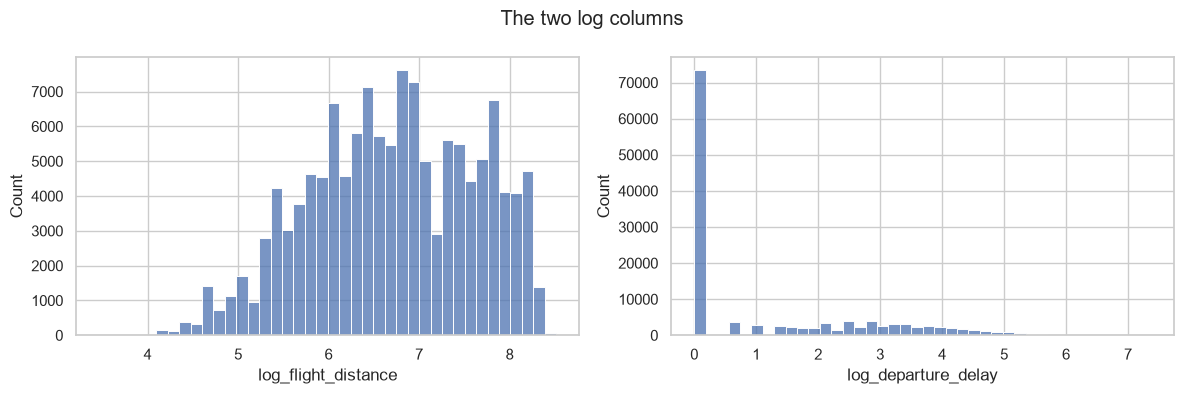

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=data, x="log_flight_distance", bins=40, ax=axes[0])
sns.histplot(data=data, x="log_departure_delay", bins=40, ax=axes[1])

fig.suptitle("The two log columns")
plt.tight_layout()
plt.savefig("../reports/figures/21_log_columns.png", dpi=120, bbox_inches="tight")
plt.show()

Observation

- here log_flight_distance (left) is a wide, bumpy hill centred around 6.7, a much more balanced shape than the original right-skewed one. 

- log_departure_delay (right) has one tall bar at 0 (the on-time flights) and then a gentle spread out to about 7.

### Train - Test - Split

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, stratify= data["satisfied"])

print("Rows for experiments (train_df):", len(train_df))
print("Rows locked away (test_df) :", len(test_df))
print("Share satisfied in train_df:", round(train_df["satisfied"].mean(), 4))
print("share satisfied in test_df:", round(test_df["satisfied"].mean(), 4))

Rows for experiments (train_df): 103904
Rows locked away (test_df) : 25976
Share satisfied in train_df: 0.4345
share satisfied in test_df: 0.4345


In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

y = train_df["satisfied"]

X_raw = pd.get_dummies(train_df[RATING_COLS + NUMERIC_COLS + CATEGORICAL_COLS],
                       columns =CATEGORICAL_COLS, drop_first=True)

model = HistGradientBoostingClassifier(random_state=42)

print(X_raw.shape)
print(list(X_raw.columns))

(103904, 23)
['departure_arrival_time_convenience', 'ease_of_online_booking', 'checkin_service', 'online_boarding', 'gate_location', 'onboard_service', 'seat_comfort', 'leg_room_service', 'cleanliness', 'food_and_drink', 'inflight_service', 'inflight_wifi_service', 'inflight_entertainment', 'baggage_handling', 'age', 'flight_distance', 'departure_delay', 'arrival_delay', 'gender_Male', 'customer_type_Returning', 'type_of_travel_Personal', 'travel_class_Economy', 'travel_class_Economy Plus']


In [11]:
experiments = {
    "1 all 22 original features": X_raw,
    "2 without wifi": X_raw.drop(columns=["inflight_wifi_service"]),
    "3 without gate_location": X_raw.drop(columns=["gate_location"]),
    "4 without gender": X_raw.drop(columns=["gender_Male"]),
    "5 without time convenience": X_raw.drop(columns=["departure_arrival_time_convenience"]),
    "6 without arrival_delay": X_raw.drop(columns=["arrival_delay"]),
    "7 without departure_delay": X_raw.drop(columns=["departure_delay"]),
    "8 plus biz_trip_biz_class": X_raw.join(train_df[["biz_trip_biz_class"]]),
    "9 plus num_not_rated": X_raw.join(train_df[["num_not_rated"]]),
    "10 plus delay_diff and is_delayed": X_raw.join(train_df[["delay_diff", "is_delayed"]]),
    "11 plus age_group": X_raw.join(train_df[["age_group"]]),
}

for name in experiments:
    scores = cross_val_score(model, experiments[name], y, cv=3)
    print(name.ljust(36), round(scores.mean() * 100, 2), "+/-", round(scores.std() * 100, 2))

1 all 22 original features           96.25 +/- 0.08
2 without wifi                       94.07 +/- 0.08
3 without gate_location              96.22 +/- 0.07
4 without gender                     96.25 +/- 0.07
5 without time convenience           96.26 +/- 0.06
6 without arrival_delay              96.23 +/- 0.06
7 without departure_delay            96.22 +/- 0.06
8 plus biz_trip_biz_class            96.3 +/- 0.06
9 plus num_not_rated                 96.23 +/- 0.03
10 plus delay_diff and is_delayed    96.26 +/- 0.06
11 plus age_group                    96.25 +/- 0.08


observation :

- Experiment 2 is the only big change. Removing wifi costs 2.18 points. That's real.

- Experiments 3 to 7: removing gate location, gender, time convenience, either delay column changes nothing you can measure (-0.03 to +0.01). These columns aren't pulling their weight. Gender and gate location have no pattern against satisfaction (Steps 3 and 4), and the two delay columns say the same thing.

- Experiments 8 to 11: none of the new columns changes the score beyond noise. The best is +0.05. Tree models find these patterns by themselves.

In [12]:
final_text = ["customer_type", "type_of_travel", "travel_class"]

final_numbers = ["age", "flight_distance", "departure_delay"]

final_ratings = ["ease_of_online_booking", "checkin_service", "online_boarding",
                 "onboard_service", "seat_comfort", "leg_room_service", "cleanliness",
                 "food_and_drink", "inflight_service", "inflight_wifi_service",
                 "inflight_entertainment", "baggage_handling"]

final_cols = final_text + final_numbers + final_ratings

# the same lists without wifi
final_ratings_no_wifi = final_ratings.copy()
final_ratings_no_wifi.remove("inflight_wifi_service")

final_cols_no_wifi = final_cols.copy()
final_cols_no_wifi.remove("inflight_wifi_service")

print("Features with wifi   :", len(final_cols))
print("Features without wifi:", len(final_cols_no_wifi))

Features with wifi   : 18
Features without wifi: 17


In [13]:
X_final = pd.get_dummies(train_df[final_cols], columns=final_text, drop_first=True)
X_final_no_wifi = pd.get_dummies(train_df[final_cols_no_wifi], columns=final_text, drop_first=True)

# the same tables with all seven candidate columns added
X_more = X_final.join(train_df[new_cols])
X_more_no_wifi = X_final_no_wifi.join(train_df[new_cols])

final_experiments = {
    "A final features, with wifi": X_final,
    "B final features + all 7 candidates, with wifi": X_more,
    "C final features, without wifi": X_final_no_wifi,
    "D final features + all 7 candidates, without wifi": X_more_no_wifi,
    "E same as D, but without num_not_rated": X_more_no_wifi.drop(columns=["num_not_rated"]),
}

for name in final_experiments:
    scores = cross_val_score(model, final_experiments[name], y, cv=3)
    print(name.ljust(52), round(scores.mean() * 100, 2), "+/-", round(scores.std() * 100, 2))

A final features, with wifi                          96.13 +/- 0.0
B final features + all 7 candidates, with wifi       96.2 +/- 0.06
C final features, without wifi                       94.05 +/- 0.1
D final features + all 7 candidates, without wifi    94.48 +/- 0.12
E same as D, but without num_not_rated               94.14 +/- 0.12


observation:

- A versus experiment 1: the final list scores 96.13, against 96.25 for all 22 original features. Dropping four columns together costs about 0.1 points. That's about 12 passengers in 10,000. We accept it, and 5.9 explains why.

- B versus A: adding all seven candidates brings back +0.07. That's noise.

- D versus C: without wifi, the candidates add +0.43. That looks like a gain, but look at E. Take away num_not_rated and the gain falls to +0.09, which is noise again.

- So num_not_rated was sneaking the wifi signal back in. Passengers who skipped wifi have a zero in that column, so counting the zeros lets the model recover "wifi was 0" even after wifi is removed. If we want an honest "without wifi" result, that column has to go.

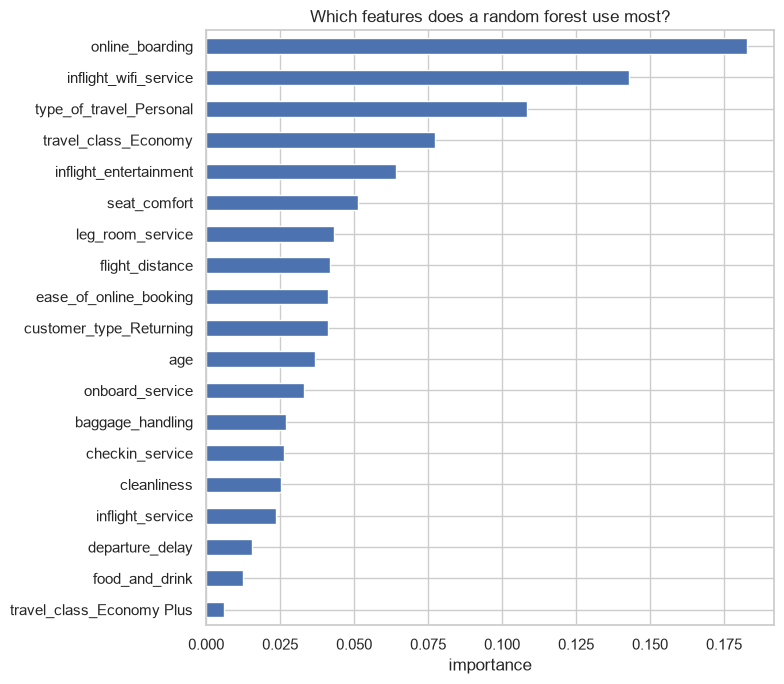

online_boarding            0.183
inflight_wifi_service      0.143
type_of_travel_Personal    0.108
travel_class_Economy       0.077
inflight_entertainment     0.064
seat_comfort               0.051
leg_room_service           0.043
flight_distance            0.042
ease_of_online_booking     0.041
customer_type_Returning    0.041
dtype: float64

In [14]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
forest.fit(X_final, y)

importance = pd.Series(forest.feature_importances_, index=X_final.columns)
importance = importance.sort_values()

plt.figure(figsize=(8, 7))
importance.plot(kind="barh")
plt.title("Which features does a random forest use most?")
plt.xlabel("importance")
plt.tight_layout()
plt.savefig("../reports/figures/22_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

importance.sort_values(ascending=False).head(10).round(3)

#### Experiment with linear model

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# fills blanks with the median, scales every column, then fits the model
lin_model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=2000))

# the final features, with the ratings turned into categories
X_lin_cat = pd.get_dummies(train_df[final_cols],
                           columns=final_text + final_ratings, drop_first=True)
X_lin_cat_no_wifi = pd.get_dummies(train_df[final_cols_no_wifi],
                                   columns=final_text + final_ratings_no_wifi, drop_first=True)

# the same, plus the age group, log columns and business flag
more_cols = final_cols + ["age_group", "log_flight_distance", "log_departure_delay", "biz_trip_biz_class"]
X_lin_more = pd.get_dummies(train_df[more_cols],
                            columns=final_text + final_ratings + ["age_group"], drop_first=True)

print("Columns with ratings as categories:", X_lin_cat.shape[1])

Columns with ratings as categories: 64


In [16]:
lin_experiments = {
    "L1 ratings as plain numbers": X_final,
    "L2 ratings as categories": X_lin_cat,
    "L3 ratings as categories, without wifi": X_lin_cat_no_wifi,
    "L4 L2 plus age group, logs, business flag": X_lin_more,
}

for name in lin_experiments:
    scores = cross_val_score(lin_model, lin_experiments[name], y, cv=3)
    print(name.ljust(44), round(scores.mean() * 100, 2), "+/-", round(scores.std() * 100, 2))

L1 ratings as plain numbers                  87.23 +/- 0.03
L2 ratings as categories                     93.25 +/- 0.11
L3 ratings as categories, without wifi       90.03 +/- 0.08
L4 L2 plus age group, logs, business flag    93.3 +/- 0.16


observation :

- here L1 to L2: +6.0 points. This is the biggest effect in the whole step. For a linear model, the way ratings are encoded matters far more than any new column. Step 8 will build this in for the linear-type models.

- L2 to L4: +0.05. Age groups, log columns and the business flag don't help a linear model either. The skew we worried about in Step 3 doesn't matter here.
L3 versus L2: wifi is worth 3.2 points to the linear model, consistent with the tree result (2.2 points).

- A tree model reaches about 96% and a linear model about 93%. The gap is real, but it's much smaller than the 87 versus 96 we'd have seen if we hadn't encoded ratings properly.

#### checking the saved features

In [17]:
from src.config import FEATURE_COLS, FEATURE_COLS_NO_WIFI
from src.features import make_features

features = make_features(df)

print("Shape:", features.shape)
print("Missing values:", features.isnull().sum().sum())
print("Same columns as the notebook version:", features.equals(data[FEATURE_COLS]))

Shape: (129880, 18)
Missing values: 0
Same columns as the notebook version: True


In [18]:
features.head()

,customer_type,type_of_travel,travel_class,age,flight_distance,departure_delay,ease_of_online_booking,checkin_service,online_boarding,onboard_service,seat_comfort,leg_room_service,cleanliness,food_and_drink,inflight_service,inflight_wifi_service,inflight_entertainment,baggage_handling
0,First-time,Business,Business,48,821,2,3,4,3,3,5,2,5,5,5,3,5,5
1,Returning,Business,Business,35,821,26,2,3,5,5,4,5,5,3,5,2,5,5
2,Returning,Business,Business,41,853,0,4,4,5,3,5,3,5,5,3,4,3,3
3,Returning,Business,Business,50,1905,0,2,3,4,5,5,5,4,4,5,2,5,5
4,Returning,Business,Business,49,3470,0,3,3,5,3,4,4,5,4,3,3,3,3


In [19]:
print("Columns with wifi   :", len(FEATURE_COLS))
print("Columns without wifi:", len(FEATURE_COLS_NO_WIFI))
print()
print(FEATURE_COLS)

Columns with wifi   : 18
Columns without wifi: 17

['customer_type', 'type_of_travel', 'travel_class', 'age', 'flight_distance', 'departure_delay', 'ease_of_online_booking', 'checkin_service', 'online_boarding', 'onboard_service', 'seat_comfort', 'leg_room_service', 'cleanliness', 'food_and_drink', 'inflight_service', 'inflight_wifi_service', 'inflight_entertainment', 'baggage_handling']


In [20]:
# one made-up passenger, the way the Streamlit app will send it later
one_passenger = pd.DataFrame([{
    "customer_type": "Returning", "type_of_travel": "Business", "travel_class": "Business",
    "age": 40, "flight_distance": 1500, "departure_delay": 10,
    "ease_of_online_booking": 4, "checkin_service": 4, "online_boarding": 4,
    "onboard_service": 4, "seat_comfort": 4, "leg_room_service": 4,
    "cleanliness": 4, "food_and_drink": 4, "inflight_service": 4,
    "inflight_wifi_service": 3, "inflight_entertainment": 4, "baggage_handling": 4,
}])

make_features(one_passenger).T

,0
customer_type,Returning
type_of_travel,Business
travel_class,Business
age,40
flight_distance,1500
departure_delay,10
ease_of_online_booking,4
checkin_service,4
online_boarding,4
onboard_service,4
